# Numerical solver for the discrete space and structured model

### Setup

Import the model and paramater class from the file model_solver

In [37]:
%load_ext autoreload
%autoreload 2

# Standard Imports
import numpy as np
import matplotlib.pyplot as plt

# Your Custom Import
from model_solver import Params, MacrophageModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Tests

#### Conservation of mass

To test conservation of mass we need to check whether the total number of macrophages stays constant as we switch death, recruitment and emigration off.
We set gamma, beta, sigma_b and sigma_max to 0, and we then set the initial conditions to have all macrophages in one spatial site (i=M/2) and one lipid class (n=0)

In [7]:
# # Define your parameters
# p = Params(
#     M=50, N=100, kplus=1, kminus=1, beta=0, D_min=0.1, gamma=0, 
#     sigma_b=0, sigma_max=0, V_tot=100000, v_max=10, theta=10, debug=True
# )

# t_final = 20.0

# # Instantiate the model
# model = MacrophageModel(p)

# # Setup Time
# t_span = (0.0, t_final)
# t_eval = np.linspace(t_span[0], t_span[1], 500)

# # 1. Start with an empty grid
# u0 = np.zeros((model.p.M + 1, model.p.N + 1))

# # 2. Put a spike of empty macrophages (n=0) exactly in the middle of the spatial grid
# middle_node = model.p.M // 2
# u0[middle_node, 0] = 0.5  # Set concentration to 0.5 (must be < 1.0 to obey phi bounds)

# # 3. Flatten for the solver
# y0 = u0.ravel()

# U, sol = model.solve(t_span, t_eval, y0=y0)
# results = model.compute_diagnostics(U)

# # Extract the total macrophage number over time
# total_macrophages = results["totals"]["macrophage_number"]
# total_cell_volume = results["totals"]["cell_volume"]
# total_density = results["totals"]["cell_density"]

# # Check the difference between the very first time step and the very last
# initial_mass = total_macrophages[0]
# final_mass = total_macrophages[-1]
# mass_error = np.abs(final_mass - initial_mass)

# print(f"Initial Total Cell Mass: {initial_mass:.6f}")
# print(f"Final Total Cell Mass:   {final_mass:.6f}")
# print(f"Absolute Conservation Error: {mass_error:.2e}")


Initial Total Cell Mass: 1000.000000
Final Total Cell Mass:   999.999901
Absolute Conservation Error: 9.89e-05


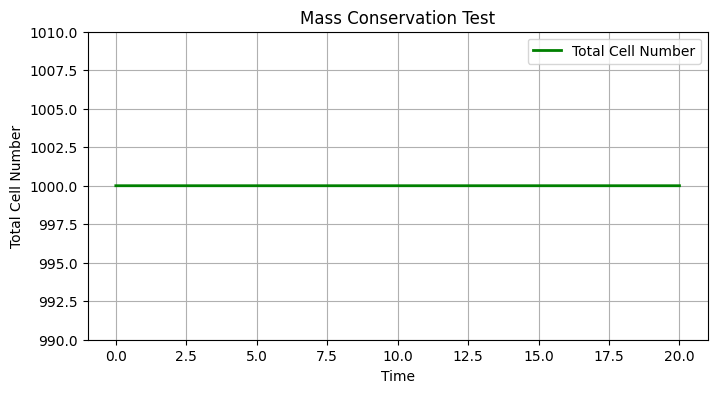

In [8]:
# plt.figure(figsize=(8, 4))
# plt.plot(sol.t, total_macrophages, label="Total Cell Number", color='green', linewidth=2)
# plt.ylim(initial_mass * 0.99, initial_mass * 1.01) # Set y-axis to start at 0 so you can see it's flat
# plt.title("Mass Conservation Test")
# plt.xlabel("Time")
# plt.ylabel("Total Cell Number")
# plt.legend()
# plt.grid(True)
# plt.show()

#### Grid indipendence (spatial M)

In [12]:
# # 1. Define your base biological parameters (Everything EXCEPT M)
# base_params = dict(
#     N=100, kplus=1, kminus=1, beta=2, D_min=0.1, gamma=0.2,
#     sigma_b=0.004, sigma_max=0.4, V_tot=100000, v_max=10, theta=10, debug=True
# )

# M_values = [25, 50, 100]

# # Dictionary to just store the spatial arrays for each M
# spatial_results = {}

# # 2. Run the simulations
# t_span = (0.0, 20.0)
# t_eval = np.linspace(t_span[0], t_span[1], 200)

# for M in M_values:
#     print(f"Simulating M = {M}...")
#     p = Params(M=M, **base_params) 
#     model = MacrophageModel(p)
#     U, sol = model.solve(t_span, t_eval)
    
#     # Compute diagnostics and save ONLY the spatial dictionary
#     diagnostics = model.compute_diagnostics(U)
#     spatial_results[M] = diagnostics["spatial"]

# print("Done! Plotting profiles...")

Simulating M = 25...
Simulating M = 50...
Simulating M = 100...
Done! Plotting profiles...


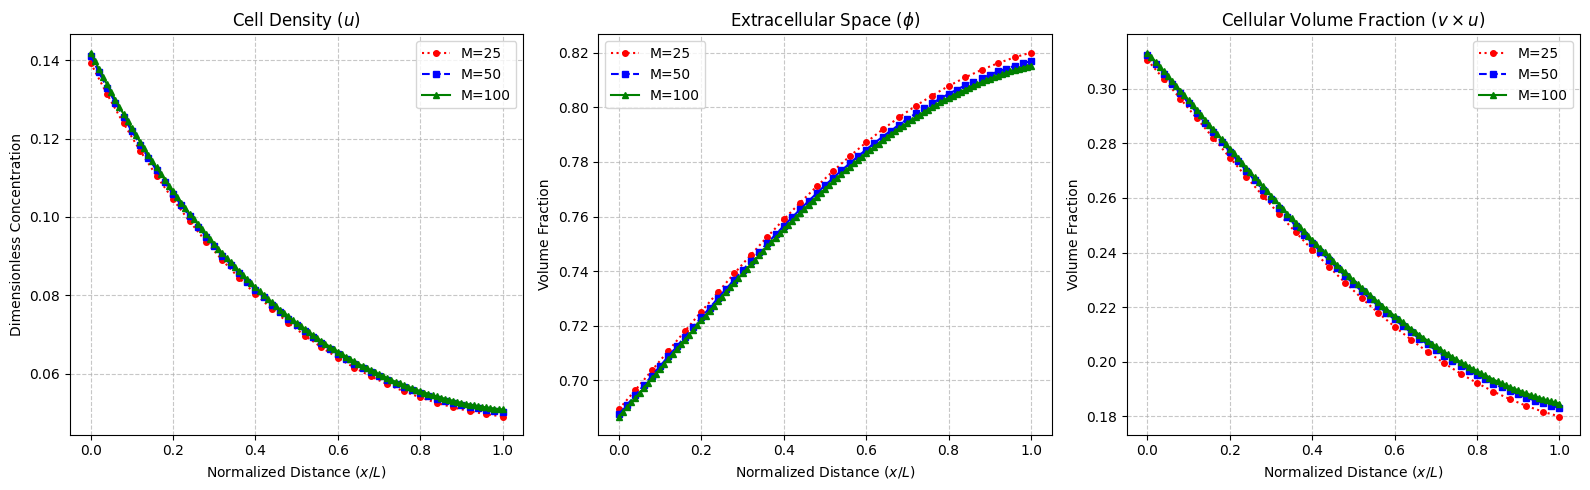

In [ ]:
# # 3. Plot the Spatial Profiles Side-by-Side (WITH MARKERS)
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# colors = {25: 'red', 50: 'blue', 100: 'green'}
# line_styles = {25: ':', 50: '--', 100: '-'}
# # NEW: Define a unique marker shape for each grid resolution
# markers = {25: 'o', 50: 's', 100: '^'}  # Circle, Square, Triangle

# for M in M_values:
#     normalized_x = np.linspace(0, 1.0, M + 1)
    
#     u_profile = spatial_results[M]["cell_density"][-1, :]
#     phi_profile = spatial_results[M]["phi"][-1, :]
#     vu_profile = spatial_results[M]["volume_fraction"][-1, :]
    
#     # Added marker and markersize to each plot
#     axes[0].plot(normalized_x, u_profile, label=f'M={M}', 
#                  color=colors[M], linestyle=line_styles[M], linewidth=1.5,
#                  marker=markers[M], markersize=4)
    
#     axes[1].plot(normalized_x, phi_profile, label=f'M={M}', 
#                  color=colors[M], linestyle=line_styles[M], linewidth=1.5,
#                  marker=markers[M], markersize=4)
    
#     axes[2].plot(normalized_x, vu_profile, label=f'M={M}', 
#                  color=colors[M], linestyle=line_styles[M], linewidth=1.5,
#                  marker=markers[M], markersize=4)

# # Format the plots
# axes[0].set_title("Cell Density ($u$)")
# axes[0].set_ylabel("Dimensionless Concentration")

# axes[1].set_title(r"Extracellular Space ($\phi$)")
# axes[1].set_ylabel("Volume Fraction")

# axes[2].set_title("Cellular Volume Fraction ($v \\times u$)")
# axes[2].set_ylabel("Volume Fraction")

# for ax in axes:
#     ax.set_xlabel("Normalized Distance ($x/L$)")
#     ax.legend()
#     ax.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

#### Class resolution independence (lipid N)

In [15]:
# # 1. Define your base biological parameters (Everything EXCEPT N)
# base_params = dict(
#     M=50, kplus=1, kminus=1, beta=2, D_min=0.1, gamma=0.2,
#     sigma_b=0.004, sigma_max=0.4, V_tot=100000, v_max=10, theta=10, debug=True
# )

# N_values = [25, 50, 100]

# # Dictionary to just store the spatial arrays for each N
# structural_results = {}

# # 2. Run the simulations
# t_span = (0.0, 20.0)
# t_eval = np.linspace(t_span[0], t_span[1], 200)

# for N in N_values:
#     print(f"Simulating N = {N}...")
#     p = Params(N=N, **base_params) 
#     model = MacrophageModel(p)
#     U, sol = model.solve(t_span, t_eval)
    
#     # Compute diagnostics and save ONLY the structure dictionary
#     diagnostics = model.compute_diagnostics(U)
#     structural_results[N] = diagnostics["structure"]

# print("Done! Plotting profiles...")

Simulating N = 25...
Simulating N = 50...
Simulating N = 100...
Done! Plotting profiles...


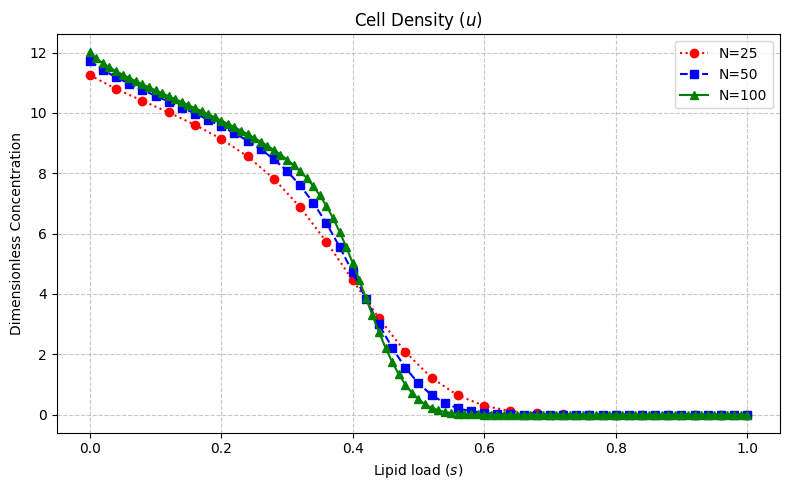

In [ ]:
# # 3. Plot the Structure Profiles Side-by-Side (WITH MARKERS)
# plt.figure(figsize=(8, 5))

# colors = {25: 'red', 50: 'blue', 100: 'green'}
# line_styles = {25: ':', 50: '--', 100: '-'}
# markers = {25: 'o', 50: 's', 100: '^'}  # Circle, Square, Triangle

# for N in N_values:
#     s = np.linspace(0, 1.0, N + 1)
    
#     u_profile = structural_results[N]["cell_density"][-1, :]
    
#     # Added marker and markersize to each plot
#     plt.plot(s, N*u_profile, label=f'N={N}', 
#                  color=colors[N], linestyle=line_styles[N], linewidth=1.5,
#                  marker=markers[N], markersize=6)


# # Format the plots
# plt.title("Cell Density ($u$)")
# plt.ylabel("Dimensionless Concentration")
# plt.xlabel("Lipid load ($s$)")
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

#### Solver tolerance sensitivity

In [ ]:
# import time

# # 1. Setup Time
# t_span = (0.0, 20.0)
# t_eval = np.linspace(t_span[0], t_span[1], 200)

# # ==========================================
# # RUN 1: Baseline Tolerance (tol = 1e-5)
# # ==========================================
# print("Simulating Baseline Tolerance (1e-5)...")
# start_1 = time.time()

# p_base = Params(M=50, N=50, kplus=1, kminus=1, beta=2, D_min=0.1, gamma=0.2,
#     sigma_b=0.004, sigma_max=0.4, V_tot=100000, v_max=10, theta=10, debug=False, 
#                 tol=1e-5) # <-- BASELINE

# model_base = MacrophageModel(p_base)
# U_base, sol_base = model_base.solve(t_span, t_eval)
# diag_base = model_base.compute_diagnostics(U_base)

# time_base = time.time() - start_1
# print(f"Finished in {time_base:.2f} seconds.")


# # ==========================================
# # RUN 2: Strict Tolerance (tol = 1e-8)
# # ==========================================
# print("\nSimulating Strict Tolerance (1e-8)...")
# start_2 = time.time()

# p_strict = Params(M=50, N=100, kplus=1, kminus=1, beta=2, D_min=0.1, gamma=0.2,
#     sigma_b=0.004, sigma_max=0.4, V_tot=100000, v_max=10, theta=10, debug=False,
#                   tol=1e-8) # <-- STRICT (1000x smaller error allowed)

# model_strict = MacrophageModel(p_strict)
# U_strict, sol_strict = model_strict.solve(t_span, t_eval)
# diag_strict = model_strict.compute_diagnostics(U_strict)

# time_strict = time.time() - start_2
# print(f"Finished in {time_strict:.2f} seconds.")

Simulating Baseline Tolerance (1e-5)...
Finished in 2.13 seconds.

Simulating Strict Tolerance (1e-8)...
Finished in 5.86 seconds.



Plotting tolerance comparison...


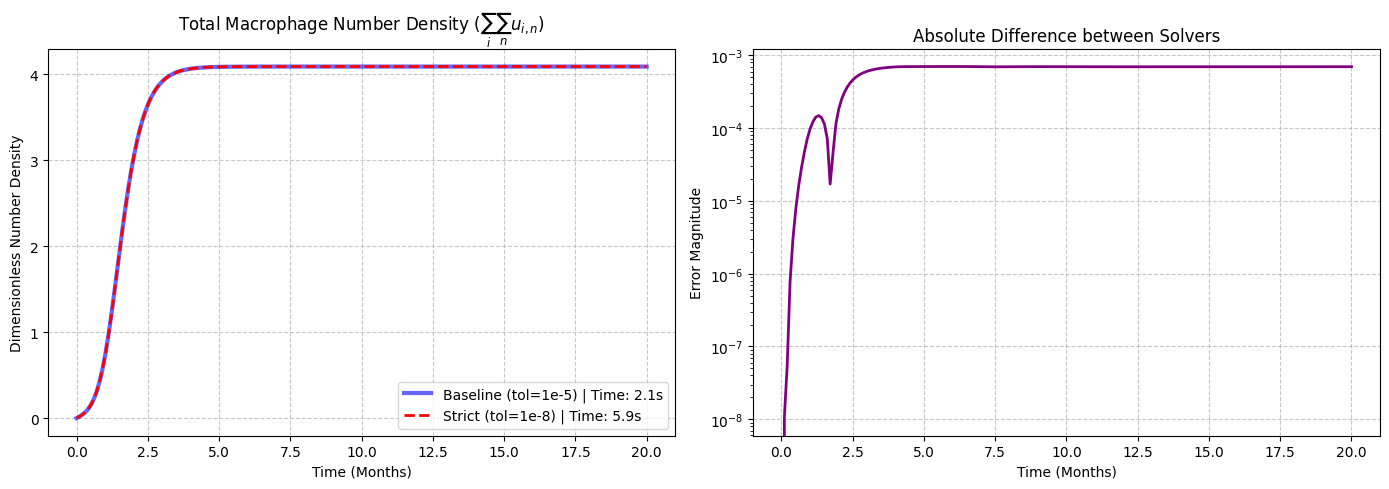

In [42]:
# # ==========================================
# # PLOTTING THE RESULTS
# # ==========================================
# print("\nPlotting tolerance comparison...")

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Extract macroscopic values (Total Lipid is usually the best metric for error)
# lipid_base = diag_base["totals"]["cell_density"]
# lipid_strict = diag_strict["totals"]["cell_density"]

# # --- Plot 1: The Macroscopic Overlay ---
# axes[0].plot(sol_base.t, lipid_base, label=f'Baseline (tol=1e-5) | Time: {time_base:.1f}s', 
#              color='blue', linewidth=3, alpha=0.6)
# axes[0].plot(sol_strict.t, lipid_strict, label=f'Strict (tol=1e-8) | Time: {time_strict:.1f}s', 
#              color='red', linestyle='--', linewidth=2)

# axes[0].set_title(r"Total Macrophage Number Density ($\sum_i \sum_n u_{i,n}$)")
# axes[0].set_xlabel("Time (Months)")
# axes[0].set_ylabel("Dimensionless Number Density")
# axes[0].legend()
# axes[0].grid(True, linestyle='--', alpha=0.7)

# # --- Plot 2: The Absolute Error (The Difference) ---
# # This shows exactly how much the solution changed between the two runs
# absolute_difference = np.abs(lipid_strict - lipid_base)

# axes[1].plot(sol_base.t, absolute_difference, color='purple', linewidth=2)
# axes[1].set_title("Absolute Difference between Solvers")
# axes[1].set_xlabel("Time (Months)")
# axes[1].set_ylabel("Error Magnitude")
# # Use a log scale for the y-axis because the error should be tiny!
# axes[1].set_yscale('log') 
# axes[1].grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

### Parameters and execution

In [4]:
# Define your parameters
p = Params(
    M=50, N=100, kplus=1, kminus=1, beta=2, D_min=0.1, gamma=0.2,
    sigma_b=0.004, sigma_max=0.4, V_tot=100000, v_max=10, theta=10, debug=True
)

t_final = 20.0

In [5]:
# Instantiate the model
model = MacrophageModel(p)

# Setup Time
t_span = (0.0, t_final)
t_eval = np.linspace(t_span[0], t_span[1], 500)
u0 = 1/(model.p.N * model.p.M) * np.ones((model.p.M + 1, model.p.N + 1))  # Initial condition: uniform distribution
y0 = u0.ravel()  # Flatten the initial condition for the solver

# Run the solver!
print("Starting solver...")
U, sol = model.solve(t_span, t_eval)
print(f"Solver finished successfully: {sol.success}")

# Check if the results are obey the physics
model.validate_results(U)

# Extract all data
results = model.compute_diagnostics(U)

Starting solver...
Solver finished successfully: True
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------


### Plotting and analysis

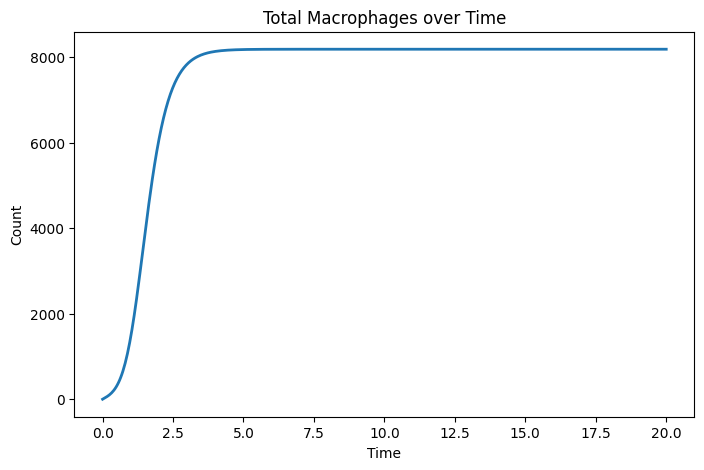

In [6]:
# Plot total macrophages over time
plt.figure(figsize=(8, 5))
plt.plot(sol.t, results["totals"]["macrophage_number"], linewidth=2)
plt.title("Total Macrophages over Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.grid(False)
plt.show()